In this notebook we'll focus more on passenger behavior & ridership volume. We'll combine ridership, vehicles, and routes to link passenger activity with specific buses and routes.

We'll start by reimporting the libraries we'll use, loading the same datasets as before and reformating the timestamps for ridership.csv.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
bus_breaks = pd.read_csv("../rutgers_bus_data/bus_breaks.csv")
stops = pd.read_csv("../rutgers_bus_data/stops.csv")
ridership = pd.read_csv("../rutgers_bus_data/ridership.csv")
routes = pd.read_csv("../rutgers_bus_data/routes.csv")
vehicles = pd.read_csv("../rutgers_bus_data/vehicles.csv")

Since ridership.csv logs the number of riders in each bus in 5-minute intervals starting from 6:00 am and ending at approximately 3:00 am the next day, we'll convert the time field into a readable timestamp so we can aggregate volume later. For the sake of consistency, we'll assume ridership takes place on October 1st, 2025, as does bus_breaks.csv. We'll also categorize ridership times into bins like we did earlier.

In [41]:
ridership = ridership[ridership["time"].between(0, 1260)]

In [42]:
ridership["timestamp"] = pd.to_datetime("2025-10-01 06:00:00") + pd.to_timedelta(ridership["time"], unit="m")
ridership["hour"] = ridership["timestamp"].dt.hour

In [43]:
def group_time(hour):
    if 6 <= hour < 12:
        return "Morning (6-11 AM)"
    elif 12 <= hour < 16:
        return "Midday (12-3 PM)"
    elif 16 <= hour < 18:
        return "Rush Hour (4-6 PM)"
    elif 18 <= hour < 21:
        return "Evening (6-9 PM)"
    else:
        return "Off Hours"

ridership["time_period"] = ridership["hour"].apply(group_time)

In [44]:
ridership

,bus_id,time,ridership_count,timestamp,hour,time_period
0,19399,0,4,2025-10-01 06:00:00,6,Morning (6-11 AM)
1,13216,0,17,2025-10-01 06:00:00,6,Morning (6-11 AM)
2,15189,0,1,2025-10-01 06:00:00,6,Morning (6-11 AM)
3,15185,0,16,2025-10-01 06:00:00,6,Morning (6-11 AM)
4,19051,0,18,2025-10-01 06:00:00,6,Morning (6-11 AM)
...,...,...,...,...,...,...
807,19051,1255,24,2025-10-02 02:55:00,2,Off Hours
808,15189,1260,8,2025-10-02 03:00:00,3,Off Hours
809,19051,1260,22,2025-10-02 03:00:00,3,Off Hours
810,15185,1260,4,2025-10-02 03:00:00,3,Off Hours


Now that ridership.csv timestamps are more readible, let's merge it with the operational data from vehicles.csv and routes.csv. Since vehicles.csv links each bus to a single route, and routes.csv defines the short codes, we can tie all three to form a single view.

Like previously, we'll extract the lowercase codes from vehicles.routeName for clean joining.

In [45]:
vehicles["routeName_short"] = (vehicles["routeName"].str.extract(r"([A-Za-z]+)")[0].str.lower())

routes["route_id"] = routes["route_id"].str.lower()

ridership_vehicles = ridership.merge(vehicles, left_on="bus_id", right_on="id", how="left")

ridership_full = ridership_vehicles.merge(routes, left_on="routeName_short", right_on="route_id", how="left")

ridership_full.head()

,bus_id,time,ridership_count,timestamp,hour,time_period,id,name,routeId,routeName,routeName_short,route_id,stop_sequence
0,19399,0,4,2025-10-01 06:00:00,6,Morning (6-11 AM),19399.0,4063,55368.0,H Route,h,h,"1,2,3,11,10,8,7,5"
1,13216,0,17,2025-10-01 06:00:00,6,Morning (6-11 AM),13216.0,4040,54545.0,LX Route,lx,lx,"1,2,3,12,13,14"
2,15189,0,1,2025-10-01 06:00:00,6,Morning (6-11 AM),15189.0,130,59451.0,B/L Loop,b,b,"12,13,14,6,9,10"
3,15185,0,16,2025-10-01 06:00:00,6,Morning (6-11 AM),15185.0,126,54543.0,EE Route,ee,ee,"1,2,23,17,18,19,20,21,16,22,3"
4,19051,0,18,2025-10-01 06:00:00,6,Morning (6-11 AM),19051.0,4061,54551.0,REXL Route,rexl,rexl,"17,18,16,12,13"


In [46]:
ridership_full['routeName'].value_counts()

routeName
EE Route      247
B/L Loop      209
REXL Route    130
LX Route      116
H Route        77
Name: count, dtype: int64

After merging ridership.csv with routes.csv and vehicles.csv, we notice less unique values for routes. This is due to the fact that the ridership for the missing routes weren't recorded in the data window we're analyzing. Fortunately for us, the routes that **are** present in ridership_full are the most passenger-dense routes, which will be beneficial for our analysis.

Let's verify whether or not the dataset gives consistent coverage of bus ridership throughout operational hours, so each period of the day can be represented evenly.

Text(0, 0.5, 'Num of Entries')

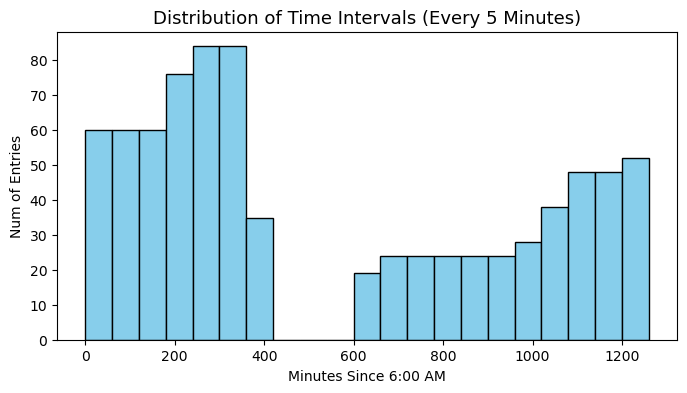

In [47]:
first_time = ridership_full["time"].min()
last_time = ridership_full["time"].max()

plt.figure(figsize=(8,4))
plt.hist(ridership_full["time"], bins=range(0, int(last_time)+60, 60), color="skyblue", edgecolor="black")
plt.title("Distribution of Time Intervals (Every 5 Minutes)", fontsize=13)
plt.xlabel("Minutes Since 6:00 AM")
plt.ylabel("Num of Entries")

We see that there is dense coverage of entries in the early morning hours, with a lesser but stil moderate number late at night, but surprisingly little data in between. It's likely that the dataset isn't continous across the entire day and only includes partial service intervals. It would be better for us not to use raw totals across time bins to avoid any misleading conclusions. We'll need to focus on relative activity levels instead of absolute counts of entries.

We'll divide the day into key periods and calculate the average number of riders per 5-minute interval for each route, so we can see which routes remain consistently busy and when their peak periods might occur.

In [48]:
def period(minutes):
    if 0 <= minutes < 360: 
        return "Morning"
    elif 360 <= minutes < 540:
        return "Midday"
    elif 540 <= minutes < 720:
        return "Rush Hour"
    elif 720 <= minutes < 1020:
        return "Evening"
    else:
        return "Late Night"

ridership_full["time_period"] = ridership_full["time"].apply(period)

In [49]:
ridership_full.head()

,bus_id,time,ridership_count,timestamp,hour,time_period,id,name,routeId,routeName,routeName_short,route_id,stop_sequence
0,19399,0,4,2025-10-01 06:00:00,6,Morning,19399.0,4063,55368.0,H Route,h,h,"1,2,3,11,10,8,7,5"
1,13216,0,17,2025-10-01 06:00:00,6,Morning,13216.0,4040,54545.0,LX Route,lx,lx,"1,2,3,12,13,14"
2,15189,0,1,2025-10-01 06:00:00,6,Morning,15189.0,130,59451.0,B/L Loop,b,b,"12,13,14,6,9,10"
3,15185,0,16,2025-10-01 06:00:00,6,Morning,15185.0,126,54543.0,EE Route,ee,ee,"1,2,23,17,18,19,20,21,16,22,3"
4,19051,0,18,2025-10-01 06:00:00,6,Morning,19051.0,4061,54551.0,REXL Route,rexl,rexl,"17,18,16,12,13"


Since we've assigned each record in ridership_full.csv to a time period, we can look at how ridership intensity varies throughout the day along each route. Since the data records every 5-minute interval per bus, we can aggregate ridership by its routeId and time_period to find the average ridership per route in each period.

In [50]:
route_time_sum = (ridership_full.groupby(["routeId", "time", "time_period"])["ridership_count"].sum().reset_index())

avg_ridership = (route_time_sum.groupby(["routeId", "time_period"])["ridership_count"].mean().reset_index())

route_names = ridership_full[["routeId", "routeName"]].drop_duplicates()
avg_ridership = avg_ridership.merge(route_names, on="routeId", how="left")

In [51]:
avg_ridership

,routeId,time_period,ridership_count,routeName
0,54543.0,Evening,14.066667,EE Route
1,54543.0,Late Night,10.489796,EE Route
2,54543.0,Midday,11.800000,EE Route
3,54543.0,Morning,16.333333,EE Route
4,54543.0,Rush Hour,3.050000,EE Route
5,54545.0,Late Night,15.179487,LX Route
6,54545.0,Midday,8.200000,LX Route
7,54545.0,Morning,15.763889,LX Route
8,54551.0,Evening,6.250000,REXL Route
9,54551.0,Late Night,17.020408,REXL Route


The table above summarizes the average number of riders per 5-minute interval for each route at different poinst of the day. But some values appear inflated, for example the H route shows a midday average of 28 riders, which isn't very consistent in comparison to the other routes. Let's look at the number of entries along the H route to see if it was impacted by outliers or unusually high peaks.

In [52]:
ridership_full[ridership_full["routeName"] == "H Route"]["time_period"].value_counts()

time_period
Morning    72
Midday      5
Name: count, dtype: int64

From this, we see that the H route only has 5 entries logged during the midday period compared to 72 entries in the morning. This confirms that the extremely high average ridership at Midday was due to limited sampling. Let's inspect the actual distribution of sample counts to see what's a typical amount that we can set a cutoff for.

In [53]:
sample_counts = (ridership_full.groupby(["routeName", "time_period"])["ridership_count"].count().reset_index(name="n_samples").sort_values("n_samples", ascending=False))

In [54]:
sample_counts

,routeName,time_period,n_samples
8,EE Route,Morning,108
18,REXL Route,Morning,72
14,LX Route,Morning,72
3,B/L Loop,Morning,72
11,H Route,Morning,72
0,B/L Loop,Evening,60
5,EE Route,Evening,60
6,EE Route,Late Night,49
1,B/L Loop,Late Night,49
16,REXL Route,Late Night,49


Data coverage varies pretty heavily by time period. Morning periods are very well represented, evening and late night have moderate coverage, rush hour has partial coverage, and midday is extremely limited. We likely won't be able to use midday and rush-hour windows due to such limited sampling. We'll set a minimum threshold of 20 sammples per route-period to keep only well-represented route-time period combinations.

In [55]:
filtered_counts = sample_counts[sample_counts["n_samples"] >= 20]
filtered_counts

,routeName,time_period,n_samples
8,EE Route,Morning,108
18,REXL Route,Morning,72
14,LX Route,Morning,72
3,B/L Loop,Morning,72
11,H Route,Morning,72
0,B/L Loop,Evening,60
5,EE Route,Evening,60
6,EE Route,Late Night,49
1,B/L Loop,Late Night,49
16,REXL Route,Late Night,49


Let's go ahead and export ridership_full, avg_ridership, and filtered_counts:
* ridership_full.csv will include the cleaned and merged raw ridership data, which can be used for re-aggregation later.
* avg_ridership.csv will include pre-aggregated ridership averages per route and time period.
* filtered_counts.csv will identify route-time combinations with enough samples.

In [56]:
ridership_full.to_csv("ridership_full.csv", index=False)
avg_ridership.to_csv("avg_ridership.csv", index=False)
filtered_counts.to_csv("filtered_counts.csv", index=False)

**Notebook 2 Outcomes:**
* Merged ridership.csv, vehicles.csv, and routes.csv into unified dataset - ridership_full.csv, each entry now connects a 5-minute ridership snapshot to a specific bus + route
* Converted raw timestamps into standardized bins
* Identified uneven sampling between timestamps, decided to rely on relative averages instead of raw totals to avoid bias
* Computed average riders per route x tme period - avg_ridership.csv & detected outliers caused by limited sampling
* Counted entries per route-period and set a threshold of >= 20 samples, filtered results to keep at or above threshold - filtered_counts.csv

Within the next notebook, we'll merge the cleaned ridership patterns with dwell-time summaries from Notebook 1 to analyze how average dwell duration varies with passenger activity, and whether higher ridership leads to longer dwell times or reduced throughput.